In [1]:
#load Libraries

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
#load file using xarray 
ds = xr.open_dataset(r"C:\Users\SUDHIR SANDEEP\Downloads\S-OSI_-DMI_-MULT-GL_NH_CONCn__-202604121200Z\S-OSI_-DMI_-MULT-GL_NH_CONCn__-202604121200Z.nc")

#display summary of the dataset
ds

<xarray.Dataset>
Dimensions:                   (time: 1, nv: 2, xc: 760, yc: 1120)
Coordinates:
  * time                      (time) datetime64[ns] 2026-04-12T12:00:00
  * xc                        (xc) float64 -3.845e+03 -3.835e+03 ... 3.745e+03
  * yc                        (yc) float64 5.845e+03 5.835e+03 ... -5.345e+03
    lat                       (yc, xc) float32 ...
    lon                       (yc, xc) float32 ...
Dimensions without coordinates: nv
Data variables:
    Polar_Stereographic_Grid  int32 ...
    time_bnds                 (time, nv) datetime64[ns] ...
    ice_conc                  (time, yc, xc) float32 ...
    raw_ice_conc_values       (time, yc, xc) float32 ...
    status_flag               (time, yc, xc) float32 ...
    total_uncertainty         (time, yc, xc) float32 ...
    smearing_uncertainty      (time, yc, xc) float32 ...
    algorithm_uncertainty     (time, yc, xc) float32 ...
Attributes: (12/30)
    title:                   Level-3 Sea Ice Concentration Analysis (SSMIS) f...
    product_id:              OSI-401-d
    instrument_type:         SSMIS (Multi-sensor analysis)
    platform_name:           SSMIS F16, F17, F18
    easternmost_longitude:   180.0
    westernmost_longitude:   -180.0
    ...                      ...
    references:              Product User Manual and Algorithm Theoretical Ba...
    history:                 Created 2026-04-13 04:00:51
    product_version:         4.1
    software_version:        2.0.4
    netcdf_version:          1.5.4
    Conventions:             CF-1.6

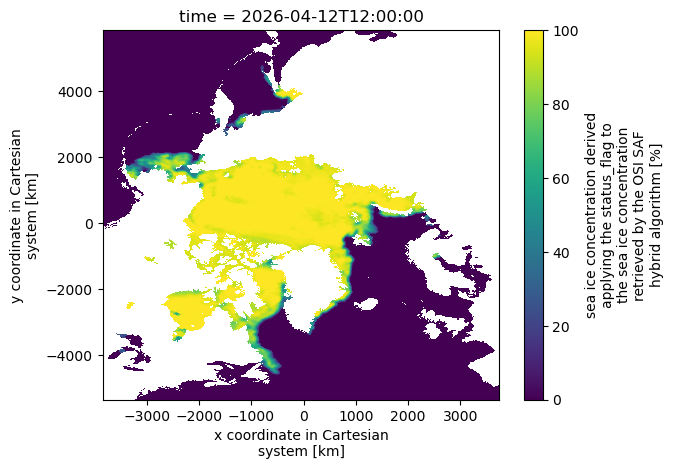

In [3]:
#plot data variable

ds['ice_conc'].plot()

In [10]:
#inspect variable types
for var_name, da in ds.data_vars.items():
    print(var_name, da.dtype, da.dims)

Polar_Stereographic_Grid int32 ()
time_bnds datetime64[ns] ('time', 'nv')
ice_conc float32 ('time', 'yc', 'xc')
raw_ice_conc_values float32 ('time', 'yc', 'xc')
status_flag float32 ('time', 'yc', 'xc')
total_uncertainty float32 ('time', 'yc', 'xc')
smearing_uncertainty float32 ('time', 'yc', 'xc')
algorithm_uncertainty float32 ('time', 'yc', 'xc')


In [11]:
#define data projection
data_crs = ccrs.NorthPolarStereo()

#define plot projection
plot_crs = ccrs.NorthPolarStereo()

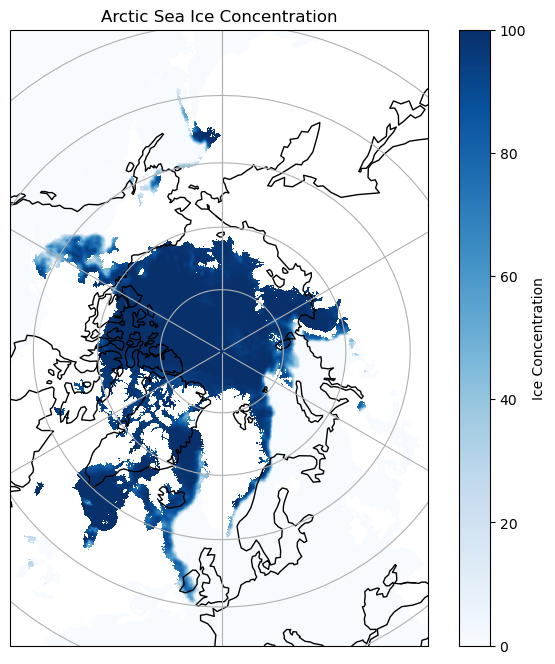

In [16]:
fig = plt.figure(figsize=(8, 8))

#create an axis with a polar stereographic projection
ax = plt.axes(projection=plot_crs)

# Select the variable
da = ds["ice_conc"].isel(time=0)

#define x and y coordinates and convert them to meters
x = ds["xc"].values * 1000  
y = ds["yc"].values * 1000

#plot the data
mesh = ax.pcolormesh(
    x,              
    y,              
    da,             
    transform=data_crs, 
    cmap="Blues"    
)

ax.coastlines()
ax.gridlines()

plt.colorbar(mesh, ax=ax, label="Ice Concentration")
plt.title("Arctic Sea Ice Concentration")
plt.show()

In [24]:
!ncdump "C:\Users\SUDHIR SANDEEP\Downloads\S-OSI_-DMI_-MULT-GL_NH_CONCn__-202604121200Z\S-OSI_-DMI_-MULT-GL_NH_CONCn__-202604121200Z.nc"

netcdf C\:\\Users\\SUDHIR\ SANDEEP\\Downloads\\S-OSI_-DMI_-MULT-GL_NH_CONCn__-202604121200Z\\S-OSI_-DMI_-MULT-GL_NH_CONCn__-202604121200Z {
dimensions:
	time = 1 ;
	nv = 2 ;
	xc = 760 ;
	yc = 1120 ;
variables:
	int Polar_Stereographic_Grid ;
		Polar_Stereographic_Grid:grid_mapping_name = "polar_stereographic" ;
		Polar_Stereographic_Grid:false_easting = 0. ;
		Polar_Stereographic_Grid:false_northing = 0. ;
		Polar_Stereographic_Grid:area_extent = "\'(-3850000.0, -5350000.0, 3750000.0, 5850000.0)\'" ;
		Polar_Stereographic_Grid:semi_major_axis = 6378273. ;
		Polar_Stereographic_Grid:semi_minor_axis = 6356889.44891 ;
		Polar_Stereographic_Grid:straight_vertical_longitude_from_pole = -45. ;
		Polar_Stereographic_Grid:latitude_of_projection_origin = 90. ;
		Polar_Stereographic_Grid:standard_parallel = 70. ;
		Polar_Stereographic_Grid:proj4_string = "+proj=stere +a=6378273 +b=6356889.44891 +lat_0=90 +lat_ts=70 +lon_0=-45" ;
	double time(time) ;
		time:axis = "T" ;
		time:long_name = "refere

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)




    71.88863, 71.7991, 71.7096, 71.62011, 71.53064, 71.44118, 71.35175, 
    71.26232, 71.17292, 71.08353, 70.99416, 70.9048, 70.81547, 70.72614, 
    70.63685, 70.54756, 70.4583, 70.36905, 70.27982, 70.19061, 70.10143, 
    70.01225, 69.9231, 69.83397, 69.74485, 69.65576, 69.56669, 69.47763, 
    69.3886, 69.29958, 69.21059, 69.12162, 69.03267, 68.94373, 68.85483, 
    68.76594, 68.67707, 68.58823, 68.4994, 68.4106, 68.32182, 68.23306, 
    68.14432, 68.0556, 67.96691, 67.87824, 67.7896, 67.70097, 67.61237, 
    67.5238, 67.43524, 67.34671, 67.2582, 67.16972, 67.08125, 66.99281, 
    66.9044, 66.81602, 66.72765, 66.63931, 66.55099, 66.4627, 66.37444, 
    66.28619, 66.19798, 66.10979, 66.02161, 65.93347, 65.84536, 65.75727, 
    65.6692, 65.58116, 65.49315, 65.40517, 65.31721, 65.22927, 65.14136, 
    65.05348, 64.96562, 64.87779, 64.78999, 64.70222, 64.61447, 64.52675, 
    64.43906, 64.35139, 64.26375, 64.17614, 64.08855, 64.001, 63.91347, 
    63.82597, 63.7385, 63.65105, 63.56364

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



    14, 14, 14, 14, 14, 14, 14, 14, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 
    30, 30, 30, 30, 30, 30, 30, 30, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 
    22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 6, 22, 22, 22, 22, 22, 22, 
    22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 
    22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 
    22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 6, 6, 22, 6, 22, 
    22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 
    22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 
    22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 
    132, 132, 132, 132, 132, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 
    64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 
    64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 
    64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64,
  64, 64, 64, 64, 64, 64, 6

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

